# Proyecto: Serpientes y Escaleras como Cadena de Markov
## Objetivos C y D: Métricas de la Partida (Matriz Fundamental)

Para analizar una partida individual desde el inicio hasta el final, debemos transformar nuestra cadena de Markov original. Quitaremos la regla de encadenamiento (50 $\rightarrow$ 1) y convertiremos el estado 50 (índice 49) en un **estado absorbente** ($P_{50,50} = 1$). 

Los estados del 1 al 49 se vuelven **estados transitorios**. Esto nos permite extraer la submatriz $Q$ (probabilidades de transición entre estados transitorios) y calcular la **Matriz Fundamental $N$**:
$$N = (I - Q)^{-1}$$

El elemento $N_{i,j}$ representa el número esperado de veces que el jugador visitará la casilla $j$ asumiendo que empezó en la casilla $i$. 
Como siempre empezamos el juego en la casilla 1 (índice 0), toda la información que necesitamos para los Objetivos C y D se encuentra en la **primera fila** de la matriz $N$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))

from src.board import Board
from src.markov import build_transition_matrix
from src.metrics import get_transient_matrix, calculate_fundamental_matrix, expected_game_duration, expected_visits_per_game

# 1. Instanciamos el modelo original
board = Board("../config/board_config.yaml")
P = build_transition_matrix(board)

# 2. Modificamos P para hacer que el estado 50 (índice 49) sea absorbente
P_absorb = P.copy()
P_absorb[49, :] = 0.0
P_absorb[49, 49] = 1.0

# 3. Extraemos Q y calculamos la Matriz Fundamental N
Q = get_transient_matrix(P_absorb)
N = calculate_fundamental_matrix(Q)

print(f"Forma de la Matriz Q: {Q.shape}")
print(f"Forma de la Matriz N: {N.shape}")

Forma de la Matriz Q: (49, 49)
Forma de la Matriz N: (49, 49)


OBJETIVO C: Duración esperada de la partida
Promedio: 21.21 turnos



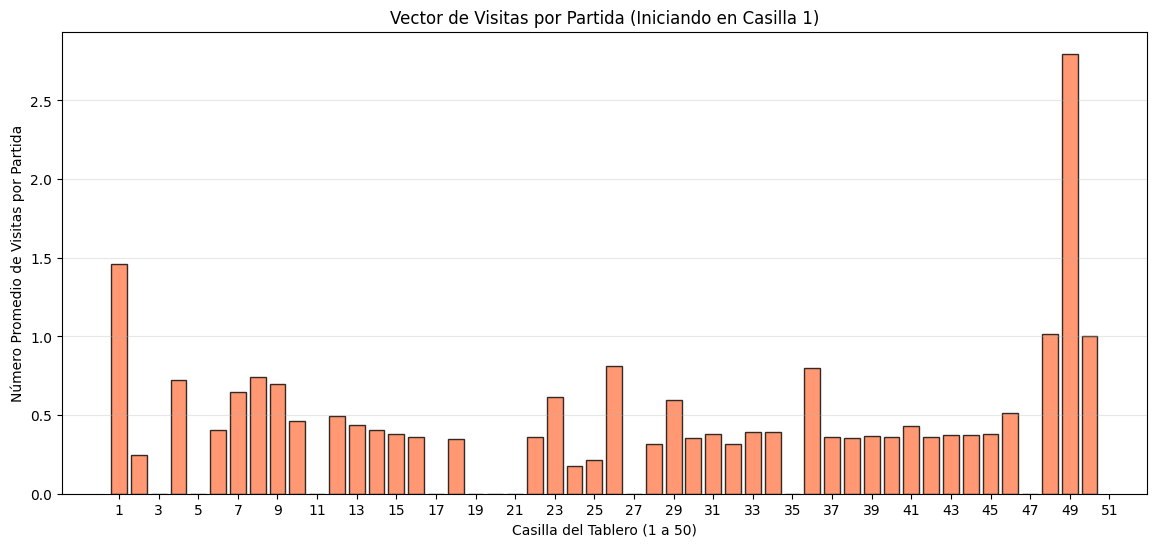

In [5]:
# --- Objetivo C: Duración Esperada ---
# La duración es la suma de todas las visitas esperadas desde el estado inicial
duracion = expected_game_duration(N)
print(f"==================================================")
print(f"OBJETIVO C: Duración esperada de la partida")
print(f"Promedio: {duracion:.2f} turnos")
print(f"==================================================\n")

# --- Objetivo D: Vector de Visitas ---
visitas = expected_visits_per_game(N)

# Graficamos el vector de visitas
plt.figure(figsize=(14, 6))
# Usamos range(1, 51) para que el eje X coincida con el número de casilla real
plt.bar(range(1, 51), visitas, color='coral', edgecolor='black', alpha=0.8)

plt.title('Vector de Visitas por Partida (Iniciando en Casilla 1)')
plt.xlabel('Casilla del Tablero (1 a 50)')
plt.ylabel('Número Promedio de Visitas por Partida')
plt.xticks(np.arange(1, 52, 2))
plt.grid(axis='y', alpha=0.3)
plt.show()

### Conclusiones: Métricas de la Partida (Objetivos C y D)

A través del uso de la Matriz Fundamental $N = (I - Q)^{-1}$, hemos aislado el comportamiento de una partida única (sin encadenamiento), obteniendo resultados que reflejan perfectamente las dinámicas del juego:

**Objetivo C: Duración Esperada**
El cálculo arroja una duración esperada de **21.21 turnos**. Esta métrica representa el balance estocástico entre el avance natural del dado (impulsado por la regla de repetición al sacar 6 y las escaleras) y la penalización de las serpientes y los rebotes al final del tablero.

**Objetivo D: Observaciones sobre el Vector de Visitas**
Al analizar la primera fila de la Matriz Fundamental, destacamos dos comportamientos principales:

1. **La Influencia de los Saltos en los Extremos:** Existen casillas con $0$ visitas esperadas (ej. 3, 5, 11, 27), las cuales corresponden a los orígenes de trampas o escaleras, impidiendo que el jugador finalice su turno en ellas. Como contraparte, las casillas destino suman las probabilidades. Un caso fascinante es la **Casilla 1**, que presenta un promedio de $\sim 1.5$ visitas. Esto se debe a que suma la visita inicial obligatoria ($1.0$) más las veces que un jugador cae en la serpiente de la casilla 27, la cual lo devuelve obligatoriamente al inicio del tablero.
2. **Fricción de Absorción (Cuello de Botella):** A medida que nos acercamos a la casilla 50, se rompe la uniformidad de las visitas. La **Casilla 49** presenta el pico máximo de todo el tablero (más de $2.5$ visitas en promedio). Esto demuestra matemáticamente el impacto de la "regla de llegada exacta": un jugador en la casilla 49 tiene una probabilidad de $5/6$ de sacar un número mayor a 1, lo que lo obliga a rebotar y sumar una visita adicional a esa misma casilla por cada turno fallido hasta lograr ganar.